### Uploading your Excel file

To load your Excel file, you'll need to upload it to your Colab environment first. You can do this by clicking the 'Files' icon on the left sidebar (folder icon), then clicking the 'Upload to session storage' icon (file with an arrow pointing up). Once uploaded, you can refer to it by its filename, for example, `your_file.xlsx`.

In [2]:
import pandas as pd

# Replace 'your_file.xlsx' with the actual name of your uploaded Excel file
# If your data is on a specific sheet, you can specify it using the 'sheet_name' argument.
# For example: df = pd.read_excel('your_file.xlsx', sheet_name='Sheet1')
df = pd.read_csv('hr_analytics.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df['Attrition_Numeric'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

attrition_rate_by_department = df.groupby('Department')['Attrition_Numeric'].mean().reset_index()
attrition_rate_by_department['Attrition_Rate'] = attrition_rate_by_department['Attrition_Numeric'] * 100

display(attrition_rate_by_department[['Department', 'Attrition_Rate']].sort_values(by='Attrition_Rate', ascending=False))

,Department,Attrition_Rate
2,Sales,20.627803
0,Human Resources,19.047619
1,Research & Development,13.839750


In [4]:
attrition_rate_by_job_role = df.groupby('JobRole')['Attrition_Numeric'].mean().reset_index()
attrition_rate_by_job_role['Attrition_Rate'] = attrition_rate_by_job_role['Attrition_Numeric'] * 100

display(attrition_rate_by_job_role[['JobRole', 'Attrition_Rate']].sort_values(by='Attrition_Rate', ascending=False))

,JobRole,Attrition_Rate
8,Sales Representative,39.759036
2,Laboratory Technician,23.938224
1,Human Resources,23.076923
7,Sales Executive,17.484663
6,Research Scientist,16.095890
4,Manufacturing Director,6.896552
0,Healthcare Representative,6.870229
3,Manager,4.901961
5,Research Director,2.500000


/tmp/ipykernel_1671/3230369385.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='JobRole', y='Attrition_Rate', data=attrition_rate_by_job_role.sort_values(by='Attrition_Rate', ascending=False), palette='viridis')


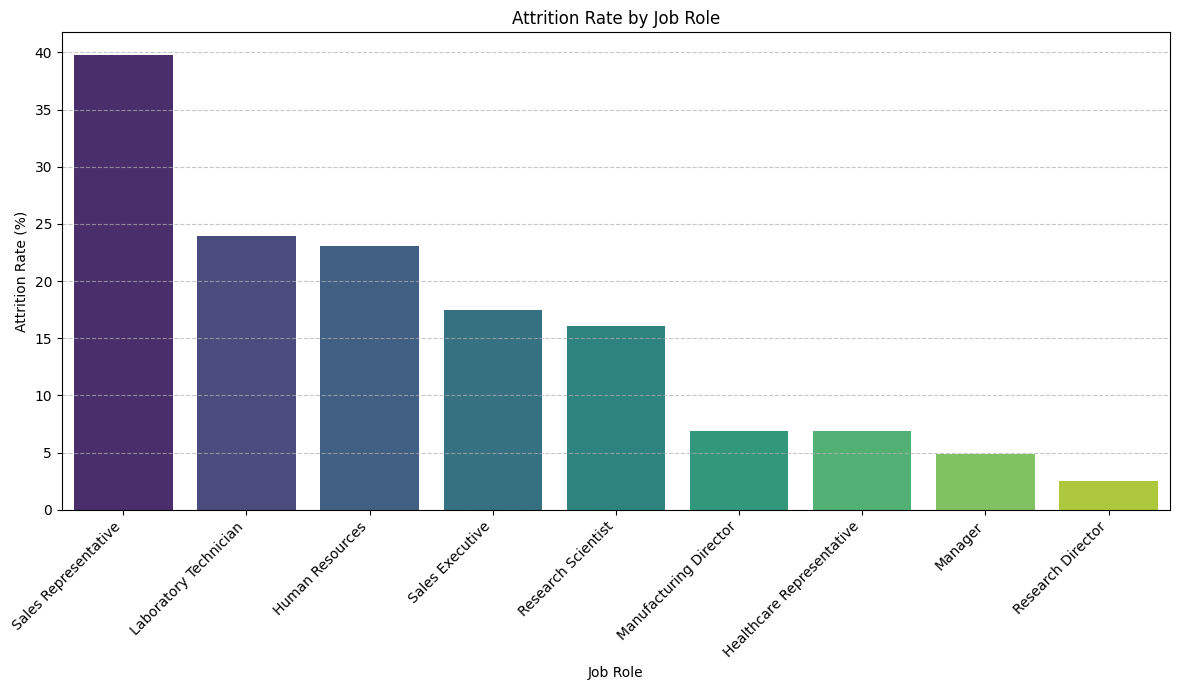

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='JobRole', y='Attrition_Rate', data=attrition_rate_by_job_role.sort_values(by='Attrition_Rate', ascending=False), palette='viridis')
plt.title('Attrition Rate by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Top 5 Senior Employees by Monthly Income

To identify senior employees, I'm assuming that `JobLevel` 4 and 5 represent senior roles. I will filter the dataset for these roles and then display the top 5 employees based on their `MonthlyIncome`, along with their `JobRole` and `JobLevel`.

In [6]:
# Filter for senior employees (JobLevel 4 and 5)
senior_employees = df[df['JobLevel'].isin([4, 5])]

# Sort by MonthlyIncome in descending order and select the top 5
top_5_senior_employees = senior_employees.sort_values(by='MonthlyIncome', ascending=False).head(5)

# Display the relevant columns
display(top_5_senior_employees[['JobRole', 'JobLevel', 'MonthlyIncome']])

,JobRole,JobLevel,MonthlyIncome
190,Manager,5,19999
746,Research Director,5,19973
851,Manager,5,19943
165,Manager,5,19926
568,Manager,5,19859


### Monthly Income Distribution for Senior Employees

This histogram shows the distribution of `MonthlyIncome` specifically for employees identified as 'senior' (JobLevel 4 or 5).

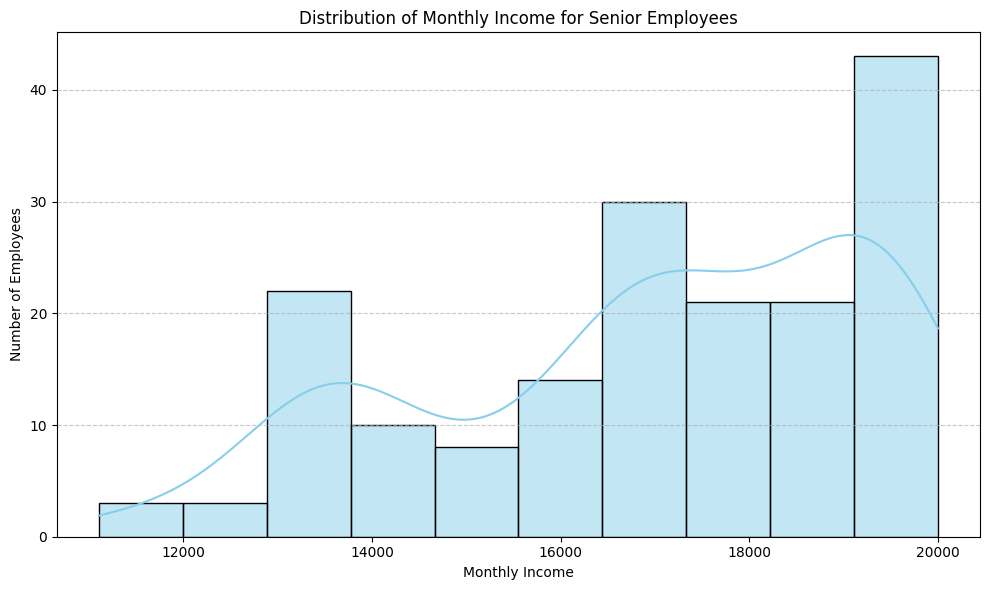

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(senior_employees['MonthlyIncome'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Monthly Income for Senior Employees')
plt.xlabel('Monthly Income')
plt.ylabel('Number of Employees')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Average Monthly Income by Job Role

This bar chart illustrates the average monthly income for each job role, providing insights into the compensation structure across different roles.

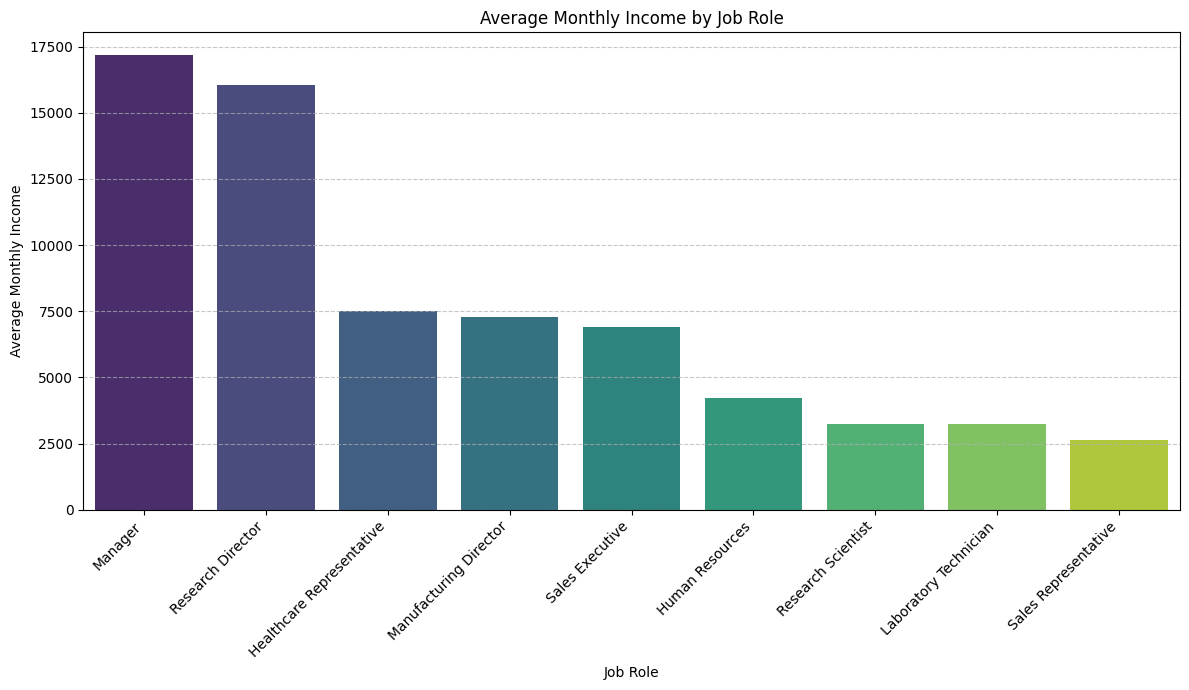

In [9]:
average_monthly_income_by_job_role = df.groupby('JobRole')['MonthlyIncome'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='JobRole', y='MonthlyIncome', data=average_monthly_income_by_job_role.sort_values(by='MonthlyIncome', ascending=False), palette='viridis', hue='JobRole', legend=False)
plt.title('Average Monthly Income by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Average Monthly Income')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Gender Distribution by Department and Job Role

This table shows the count of male and female employees within each specific department and job role, providing insight into gender distribution across different organizational segments.

In [10]:
gender_distribution = df.groupby(['Department', 'JobRole', 'Gender']).size().reset_index(name='EmployeeCount')
display(gender_distribution)

,Department,JobRole,Gender,EmployeeCount
0,Human Resources,Human Resources,Female,16
1,Human Resources,Human Resources,Male,36
2,Human Resources,Manager,Female,4
3,Human Resources,Manager,Male,7
4,Research & Development,Healthcare Representative,Female,51
5,Research & Development,Healthcare Representative,Male,80
6,Research & Development,Laboratory Technician,Female,85
7,Research & Development,Laboratory Technician,Male,174
8,Research & Development,Manager,Female,24
9,Research & Development,Manager,Male,30


### Gender Distribution by Department (Stacked Bar Chart)

This stacked bar chart visualizes the gender distribution within each department, showing the proportion of male and female employees.

In [11]:
gender_by_department = df.groupby(['Department', 'Gender']).size().unstack(fill_value=0)
display(gender_by_department)

Gender,Female,Male
Department,,
Human Resources,20,43
Research & Development,379,582
Sales,189,257


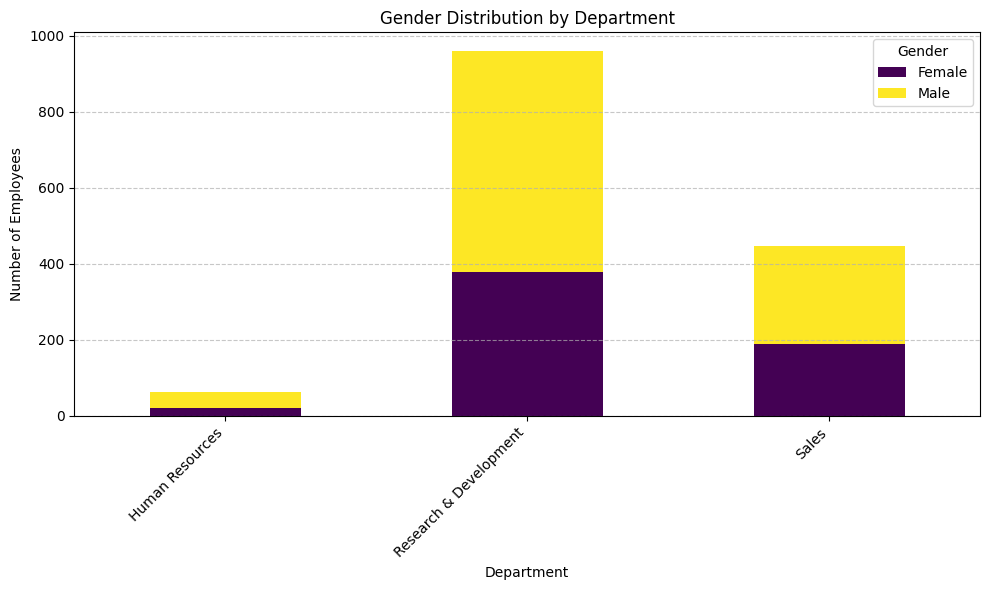

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the stacked bar chart
gender_by_department.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.title('Gender Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Job Role Seniority by Gender

Based on your request, I will categorize employees into the following seniority levels:
*   **Fresher:** JobLevel 0-1
*   **Mid-level:** JobLevel 2-3
*   **Senior:** JobLevel 4-5

Then, I will analyze the gender distribution within these seniority categories.

In [13]:
def categorize_job_seniority(job_level):
    if job_level in [0, 1]:
        return 'Fresher'
    elif job_level in [2, 3]:
        return 'Mid-level'
    elif job_level in [4, 5]:
        return 'Senior'
    else:
        return 'Other' # Handle any unexpected JobLevel values

df['JobSeniority'] = df['JobLevel'].apply(categorize_job_seniority)

# Group by JobSeniority and Gender and count employees
seniority_gender_distribution = df.groupby(['JobSeniority', 'Gender']).size().unstack(fill_value=0)
display(seniority_gender_distribution)

Gender,Female,Male
JobSeniority,,
Fresher,199,344
Mid-level,314,438
Senior,75,100


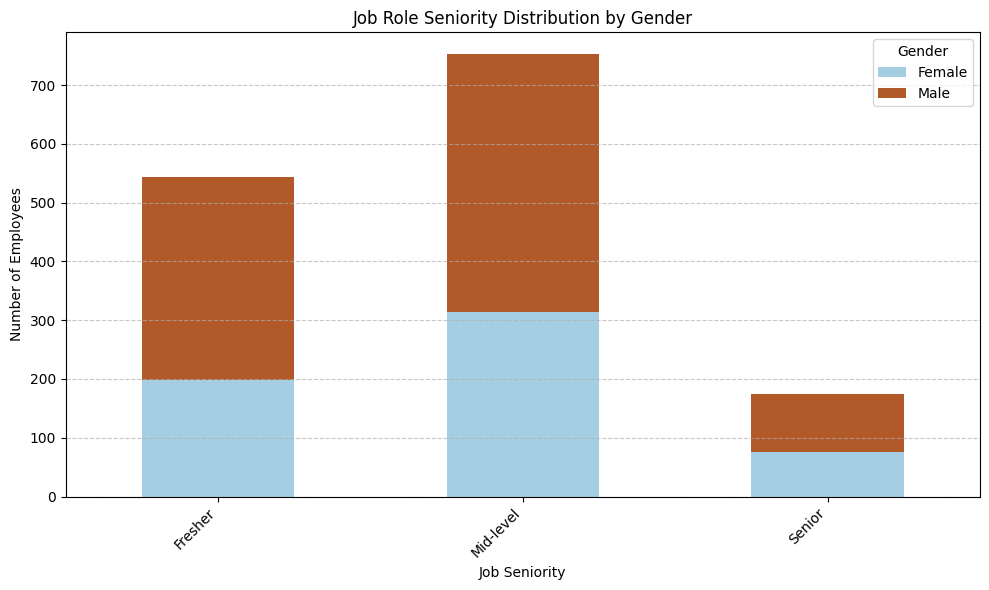

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a specific order for seniority levels for better visualization
seniority_order = ['Fresher', 'Mid-level', 'Senior']
seniority_gender_distribution = seniority_gender_distribution.reindex(seniority_order)

# Create the stacked bar chart
ax = seniority_gender_distribution.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Paired')

plt.title('Job Role Seniority Distribution by Gender')
plt.xlabel('Job Seniority')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Average Monthly Income by Department

This section calculates and visualizes the average monthly income across different departments.

In [15]:
average_monthly_income_by_department = df.groupby('Department')['MonthlyIncome'].mean().reset_index()
display(average_monthly_income_by_department.sort_values(by='MonthlyIncome', ascending=False))

,Department,MonthlyIncome
2,Sales,6959.172646
0,Human Resources,6654.507937
1,Research & Development,6281.252862


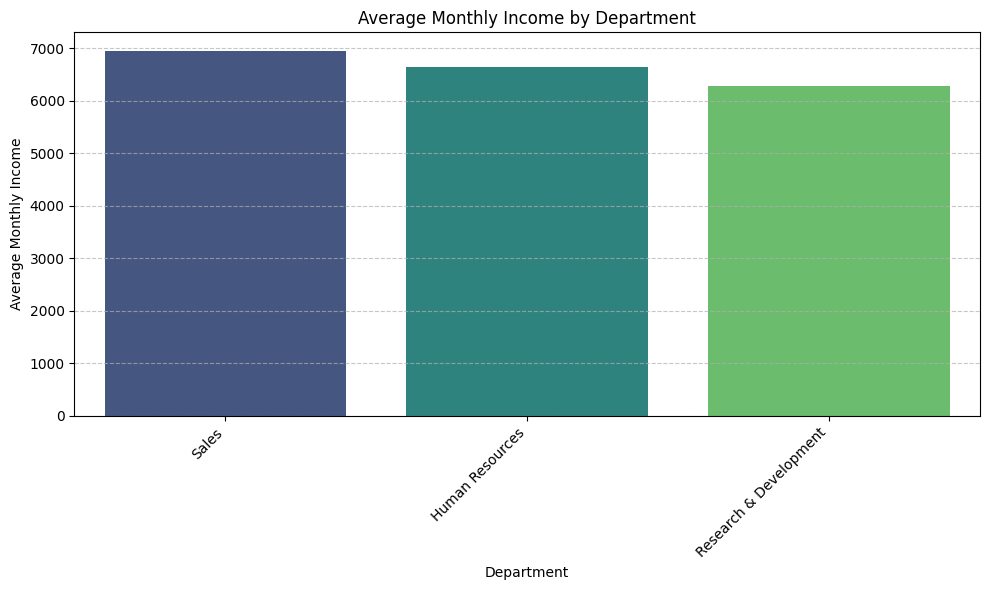

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Department', y='MonthlyIncome', data=average_monthly_income_by_department.sort_values(by='MonthlyIncome', ascending=False), palette='viridis', hue='Department', legend=False)
plt.title('Average Monthly Income by Department')
plt.xlabel('Department')
plt.ylabel('Average Monthly Income')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Key Insights from HR Analytics

Based on the analysis performed, here are the key insights:

### Attrition Analysis
*   **Departments with Highest Attrition:** Sales (20.63%) and Human Resources (19.05%) show higher attrition rates compared to Research & Development (13.84%).
*   **Job Roles with Highest Attrition:** Sales Representatives (39.76%), Laboratory Technicians (23.94%), and Human Resources (23.08%) exhibit the highest attrition rates.

### Employee Compensation and Seniority
*   **Senior Employees:** Defined by `JobLevel` 4 or 5, the top earners among senior employees have significant monthly incomes, mostly concentrated in Research & Development and Sales.
*   **Average Monthly Income by Job Role:** Manager and Research Director roles generally command the highest average monthly incomes, while Sales Representative and Laboratory Technician roles have lower average incomes.
*   **Average Monthly Income by Department:** Sales department shows the highest average monthly income ($6959.17), followed by Human Resources ($6654.51), and Research & Development ($6281.25).

### Diversity and Inclusion
*   **Gender Distribution by Department:** The stacked bar chart showed the proportion of male and female employees across Human Resources, Research & Development, and Sales departments.
*   **Job Role Seniority by Gender:**
    *   **Fresher (JobLevel 0-1):** The distribution shows more males (344) than females (199).
    *   **Mid-level (JobLevel 2-3):** Again, more males (438) than females (314).
    *   **Senior (JobLevel 4-5):** This trend continues with more males (100) than females (75) in senior roles. This suggests a potential gender imbalance that could be explored further.